In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

/home/ai/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid1_firefox_carbonyl14.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid2_firefox_carbonyl14.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid3_firefox_carbonyl14.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/odroid4_firefox_carbonyl14.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-4a_chrome_carbonyl14.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-8a_chrome_carbonyl14.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi_8b_carbonyl_onscreen_VEC14.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi_8c_carbonyl_onscreen_VEC14.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_14/rpi-8d_chrome_carbonyl14.csv")

In [15]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [16]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,Feature 12,Feature 13
0,odroid3,87.3,87.4,83.1,82.5,81.4,81.4,81.9,82.7,82.2,82.0,81.9,81.7,82.2,82.7
1,odroid4,88.6,88.4,85.7,83.9,84.3,84.3,84.2,84.8,84.1,84.4,84.8,84.2,84.2,83.9
2,rpi_8b,63.0,60.6,60.0,59.6,59.2,59.0,59.3,59.2,59.3,59.1,59.2,59.2,59.2,59.2
3,odroid4,89.5,90.6,85.4,84.1,84.0,84.1,84.1,84.3,84.0,83.7,83.8,84.0,84.7,83.9
4,rpi-8d,63.7,63.0,61.7,60.5,60.2,60.4,60.5,61.3,60.2,60.4,60.6,61.0,61.1,60.0


In [17]:
len(df)

9000

In [18]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20240910_065235"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.1.99-1 (2024-07-15)
CPU Count:          12
Memory Avail:       11.78 GB / 15.86 GB (74.3%)
Disk Space Avail:   30.75 GB / 96.93 GB (31.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240910_065235"
Train Data Rows:    1000
Train Data Columns: 14
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid3', 'odroid4', 'rpi_8b', 'rpi-8d', 'rpi-4a', 'odroid2', 'odroid1', 'rpi-8a', 'rpi_8c']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter duri

[1000]	valid_set's multi_error: 0.34


	0.6625	 = Validation score   (accuracy)
	12.04s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'RandomForestGini': 0.6, 'RandomForestEntr': 0.4}
	0.7075	 = Validation score   (accuracy)
	0.04s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 24.09s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 5985.4 rows/s (400 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("AutogluonModels/ag-20240910_065254")
Computing feature importance via permutation shuffling for 14 features using 1000 rows with 5 shuffle sets...
	7.38s	= Expected runtime (1.48s per shuffle set)
	0.79s	= Actual runtime (Completed 5 of 5 shuffle sets)
No path specified. Models will be saved in: "AutogluonModels/ag-20240910_065320"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.1

[1000]	valid_set's multi_error: 0.28875


	0.7188	 = Validation score   (accuracy)
	4.42s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7037	 = Validation score   (accuracy)
	4.05s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.6887	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.6913	 = Validation score   (accuracy)
	0.36s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7113	 = Validation score   (accuracy)
	1.44s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.6987	 = Validation score   (accuracy)
	0.35s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...


In [19]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.665754,0.648,0.645368
1,2000,0.674956,0.662,0.662747
2,3000,0.670720,0.662,0.662213
3,4000,0.682202,0.675,0.672227
4,5000,0.679422,0.666,0.666458
5,6000,0.690030,0.678,0.678781
6,7000,0.687957,0.672,0.670624
7,8000,0.695501,0.680,0.677955


<Axes: xlabel='data_amount', ylabel='value'>

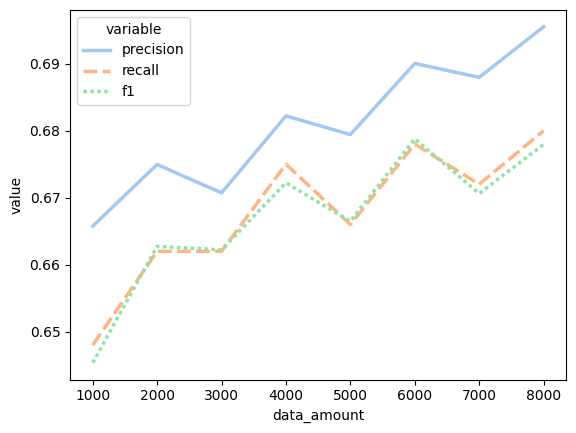

In [20]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [21]:
best_model

{'RandomForestGini': 4,
 'RandomForestEntr': 4,
 'LightGBMLarge': 3,
 'ExtraTreesEntr': 4,
 'LightGBMXT': 4,
 'ExtraTreesGini': 3,
 'WeightedEnsemble_L2': 1,
 'XGBoost': 1}

([<matplotlib.patches.Wedge at 0x7fcfb2e67610>,
 [Text(0.9526279355804298, 0.5500000148652441, 'RandomForestGini'),
  Text(-5.149471629032507e-08, 1.0999999999999988, 'RandomForestEntr'),
  Text(-0.8726887161176864, 0.6696375174382514, 'LightGBMLarge'),
  Text(-1.0625183867049497, -0.28470103251289947, 'ExtraTreesEntr'),
  Text(-0.2847008335525931, -1.0625184400161998, 'LightGBMXT'),
  Text(0.669637680852268, -0.872688590725693, 'ExtraTreesGini'),
  Text(1.0162675399543877, -0.42095164477058106, 'WeightedEnsemble_L2'),
  Text(1.0905893671152918, -0.1435786625340537, 'XGBoost')],
 [Text(0.5196152375893253, 0.30000000810831495, '17%'),
  Text(-2.8088027067450036e-08, 0.5999999999999993, '17%'),
  Text(-0.4760120269732834, 0.36525682769359163, '12%'),
  Text(-0.5795554836572453, -0.1552914722797633, '17%'),
  Text(-0.15529136375595987, -0.579555512736109, '17%'),
  Text(0.3652569168285098, -0.4760119585776507, '12%'),
  Text(0.5543277490660296, -0.22960998805668054, '4%'),
  Text(0.594866

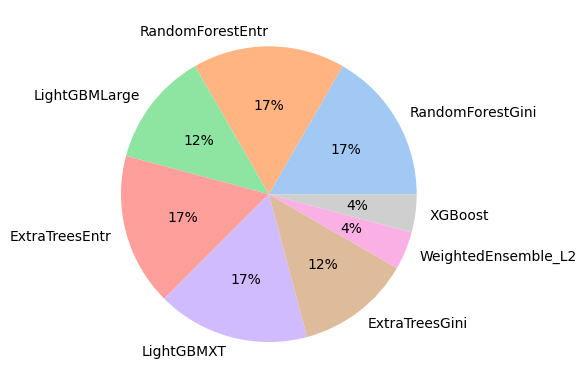

In [22]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [23]:
best_features

{'Feature 1': 8,
 'Feature 0': 6,
 'Feature 3': 7,
 'Feature 11': 1,
 'Feature 8': 2}

([<matplotlib.patches.Wedge at 0x7fd049607850>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 1'),
  Text(-1.062518426688391, 0.2847008832926707, 'Feature 0'),
  Text(-0.14357877740594213, -1.0905893519921306, 'Feature 3'),
  Text(0.8726886769326917, -0.6696375685051342, 'Feature 11'),
  Text(1.0625184133605794, -0.28470093303274774, 'Feature 8')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5795555054663949, 0.15529139088691127, '25%'),
  Text(-0.07831569676687751, -0.5948669192684347, '29%'),
  Text(0.47601200559964996, -0.365256855548255, '4%'),
  Text(0.5795554981966796, -0.15529141801786236, '8%')])

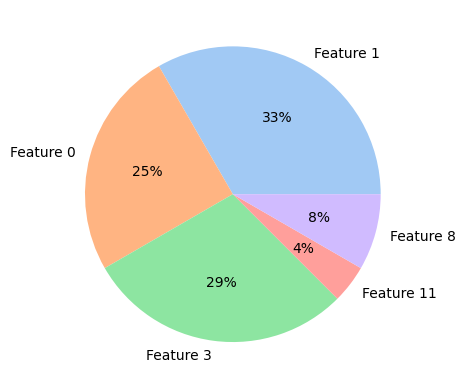

In [24]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [25]:
results

{'precision': 0.6955012288051914,
 'recall': 0.68,
 'f1-score': 0.6779554902183439,
 'support': 1000.0}